In [1]:
!pip install matplotlib numpy pandas seaborn scipy scikit-learn imbalanced-learn

По умолчанию сейчас ставится Pandas версии `3.0.1`, не стал ставить `2.х` версии. В версиях `3.х` есть некоторые отличия. Например, для `drop` с параметром `columns` не нужно указывать `axis=1`. Также в `3.х` появился отдельный тип для строкового формата.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import shapiro
from sklearn.preprocessing import MinMaxScaler
import warnings
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import re

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

In [3]:
df = pd.read_csv(f"../dataset/csv/movies.csv")
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   str    
 1   YEAR      9355 non-null   str    
 2   GENRE     9919 non-null   str    
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   str    
 5   STARS     9999 non-null   str    
 6   VOTES     8179 non-null   str    
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    str    
dtypes: float64(2), str(7)
memory usage: 703.2 KB


Удалим дубликаты, если такие имеются

In [5]:
print(f"Количество строк до удаления дублей: {len(df)}")
df.drop_duplicates(inplace=True)
print(f"Количество строк после удаления дублей: {len(df)}")

Количество строк до удаления дублей: 9999
Количество строк после удаления дублей: 9568


Колонки `MOVIES` и `ONE-LINE` содержат лишь уникальные значения, а колонка `Gross` почти пустая. Удалим их, они не будут иметь значимости для модели.

In [6]:
df.drop(columns=['MOVIES', 'ONE-LINE', 'Gross'], inplace=True)

В `VOTES` записаны числа в текстовом формате вида `21,062`, нужно их преобразовать в целые числа, так как это количество голосов.

In [7]:
df['VOTES'] = df['VOTES'].str.replace(',', '').astype('Int64')

In [8]:
df.head()

,YEAR,GENRE,RATING,STARS,VOTES,RunTime
0,(2021),"\nAction, Horror, Thriller",6.1,\n Director:\nPeter Thorwarth\n| \n Star...,21062,121.0
1,(2021– ),"\nAnimation, Action, Adventure",5.0,"\n \n Stars:\nChris Wood, \nSara...",17870,25.0
2,(2010–2022),"\nDrama, Horror, Thriller",8.2,"\n \n Stars:\nAndrew Lincoln, \n...",885805,44.0
3,(2013– ),"\nAnimation, Adventure, Comedy",9.2,"\n \n Stars:\nJustin Roiland, \n...",414849,23.0
4,(2021),"\nAction, Crime, Horror",NaN,\n Director:\nMatthias Schweighöfer\n| \n ...,<NA>,NaN


Разберёмся с `GENRE`. Для начала найдём количество всевозможных жанров

In [9]:
df['GENRE'] = df['GENRE'].str.replace('\n', '').str.replace(' ', '')

Выделим все жанры в отдельный list

In [10]:
all_genres = list(df['GENRE'].str.split(',').explode().unique())
all_genres

['Action',
 'Horror',
 'Thriller',
 'Animation',
 'Adventure',
 'Drama',
 'Comedy',
 'Crime',
 'Romance',
 'Mystery',
 'Fantasy',
 'History',
 'Sci-Fi',
 'Biography',
 'Family',
 'Documentary',
 'Music',
 'Sport',
 'Short',
 'Game-Show',
 'Reality-TV',
 'Musical',
 'War',
 'Western',
 'Film-Noir',
 nan,
 'Talk-Show',
 'News']

Создадим для каждого жанра своё поле `is_genre`

In [11]:
for genre in all_genres:
    df[f'is_{genre}'] = df['GENRE'].apply(lambda x: 1 if genre in str(x).split(',') else 0)

После чего удалим `GENRE` и ещё получившийся новый столбец `is_nan`. 

In [12]:
df.drop(columns=['GENRE', 'is_nan'], inplace=True)
df.head()

,YEAR,RATING,STARS,VOTES,RunTime,is_Action,is_Horror,is_Thriller,is_Animation,is_Adventure,is_Drama,is_Comedy,is_Crime,is_Romance,is_Mystery,is_Fantasy,is_History,is_Sci-Fi,is_Biography,is_Family,is_Documentary,is_Music,is_Sport,is_Short,is_Game-Show,is_Reality-TV,is_Musical,is_War,is_Western,is_Film-Noir,is_Talk-Show,is_News
0,(2021),6.1,\n Director:\nPeter Thorwarth\n| \n Star...,21062,121.0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,(2021– ),5.0,"\n \n Stars:\nChris Wood, \nSara...",17870,25.0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,(2010–2022),8.2,"\n \n Stars:\nAndrew Lincoln, \n...",885805,44.0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,(2013– ),9.2,"\n \n Stars:\nJustin Roiland, \n...",414849,23.0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,(2021),NaN,\n Director:\nMatthias Schweighöfer\n| \n ...,<NA>,NaN,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Закодируем поле `YEAR`.

In [13]:
# Для начала посмотрим, какой вообще вид имеет это текстовое поле 
year = df['YEAR'].unique()

In [14]:
for y in year:
    print(y)

(2021)
(2021– )
(2010–2022)
(2013– )
(2020– )
(2006–2013)
(2019– )
(2016–2021)
(2011– )
(2005– )
(2008–2013)
(2017– )
(2017–2021)
(2016– )
(1994–2004)
(2014– )
(2013–2020)
(2015– )
(2005–2020)
(2013–2022)
(2003– )
(2009–2020)
(I) (2018– )
(2010–2015)
(2011–2019)
(2015–2020)
(2005–2014)
(2009–2015)
(2008–2014)
(2016–2018)
(2009–2017)
(2020)
(2018–2021)
(2017–2020)
(1987–1994)
(2018– )
(2012– )
(2014–2020)
(2011–2018)
(2005–2017)
(2017)
(2007–2015)
(2000–2007)
(II) (2007– )
(1993)
(1999–2022)
(2015–2018)
(2014–2019)
(2016)
(2012–2020)
(2013–2019)
(2007–2012)
(2011–2020)
(2010–2017)
(2000–2015)
(2015–2021)
(2001)
(1997– )
(2011–2017)
(1993–1999)
(1989–1998)
(2010–2013)
(2010–2020)
(2003–2019)
(I) (2019)
(2017–2019)
(1975)
(2005–2008)
(1995–2001)
(2006)
(2015–2017)
(2008–2020)
(1984–1996)
(2010– )
(2014)
(2000)
(2013–2018)
(2009–2016)
(2016–2020)
(2021 TV Special)
(2003)
(1998–2003)
(I) (2017)
(1966–1969)
(2009– )
(2019)
(1990–1991)
(2012)
(1995)
(2020–2021)
(2013–2017)
(2015)
(2019–2020)


In [15]:
# Функция для парсинга
def extract_years(text):
    text = str(text)
    
    # Извлекаем год начала
    year_start_match = re.search(r'(\d{4})', text)
    year_start = year_start_match.group(1) if year_start_match else None
    
    # Извлекаем год конца
    year_end_match = re.search(r'–(\d{4})', text)
    if year_end_match:
        year_end = year_end_match.group(1)
    else:
        if re.search(r'–\s*\)', text) or re.search(r'–\s*$', text):
            year_end = None
        else:
            year_end = year_start
    
    # Извлекаем тип медиа
    media_match = re.search(r'(Video|TV\s*Movie|Video\s*Game|TV\s*Special)', text, re.IGNORECASE)
    media_type = media_match.group(1) if media_match else None
    
    return pd.Series([
        int(year_start) if year_start else None,
        int(year_end) if year_end and year_end.isdigit() else None,
        media_type
    ])

# Применяем функцию к найденному столбцу
df[['year_start', 'year_end', 'media_type']] = df['YEAR'].apply(extract_years)

# Меняем тип двух столбцов на Int64
df[['year_start', 'year_end']] = df[['year_start', 'year_end']].astype('Int64')

# Показываем результат
print(df[['YEAR', 'year_start', 'year_end', 'media_type']].head(10))

# Удалим старый столбец
df.drop(columns=['YEAR'], inplace=True)

          YEAR  year_start  year_end media_type
0       (2021)        2021      2021        NaN
1     (2021– )        2021      <NA>        NaN
2  (2010–2022)        2010      2022        NaN
3     (2013– )        2013      <NA>        NaN
4       (2021)        2021      2021        NaN
5     (2020– )        2020      <NA>        NaN
6       (2021)        2021      2021        NaN
7  (2006–2013)        2006      2013        NaN
8     (2020– )        2020      <NA>        NaN
9     (2019– )        2019      <NA>        NaN


Посмотрим, что получилось

In [16]:
df.head()

,RATING,STARS,VOTES,RunTime,is_Action,is_Horror,is_Thriller,is_Animation,is_Adventure,is_Drama,is_Comedy,is_Crime,is_Romance,is_Mystery,is_Fantasy,is_History,is_Sci-Fi,is_Biography,is_Family,is_Documentary,is_Music,is_Sport,is_Short,is_Game-Show,is_Reality-TV,is_Musical,is_War,is_Western,is_Film-Noir,is_Talk-Show,is_News,year_start,year_end,media_type
0,6.1,\n Director:\nPeter Thorwarth\n| \n Star...,21062,121.0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,2021,NaN
1,5.0,"\n \n Stars:\nChris Wood, \nSara...",17870,25.0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,<NA>,NaN
2,8.2,"\n \n Stars:\nAndrew Lincoln, \n...",885805,44.0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2010,2022,NaN
3,9.2,"\n \n Stars:\nJustin Roiland, \n...",414849,23.0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2013,<NA>,NaN
4,NaN,\n Director:\nMatthias Schweighöfer\n| \n ...,<NA>,NaN,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,2021,NaN


In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 9568 entries, 0 to 9998
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RATING          8168 non-null   float64
 1   STARS           9568 non-null   str    
 2   VOTES           8168 non-null   Int64  
 3   RunTime         7008 non-null   float64
 4   is_Action       9568 non-null   int64  
 5   is_Horror       9568 non-null   int64  
 6   is_Thriller     9568 non-null   int64  
 7   is_Animation    9568 non-null   int64  
 8   is_Adventure    9568 non-null   int64  
 9   is_Drama        9568 non-null   int64  
 10  is_Comedy       9568 non-null   int64  
 11  is_Crime        9568 non-null   int64  
 12  is_Romance      9568 non-null   int64  
 13  is_Mystery      9568 non-null   int64  
 14  is_Fantasy      9568 non-null   int64  
 15  is_History      9568 non-null   int64  
 16  is_Sci-Fi       9568 non-null   int64  
 17  is_Biography    9568 non-null   int64  
 18  is_F

Не везде есть `year_start`. Было 9355 непустых значений, осталось 8933 значения. В действительности в этом поле были значения, не содержащие года, например `(V)`.

`year_end` есть не у всех строк, но это нормально. Можно, конечно, заменить на текущий год, но NaN ведь тоже подойдёт?

Созданный `media_type` не несёт никакого смысла для модели, тоже удалим его.

In [18]:
df.drop(columns=['media_type'], inplace=True)

Посмотрим как распределена переменная `RunTime` 

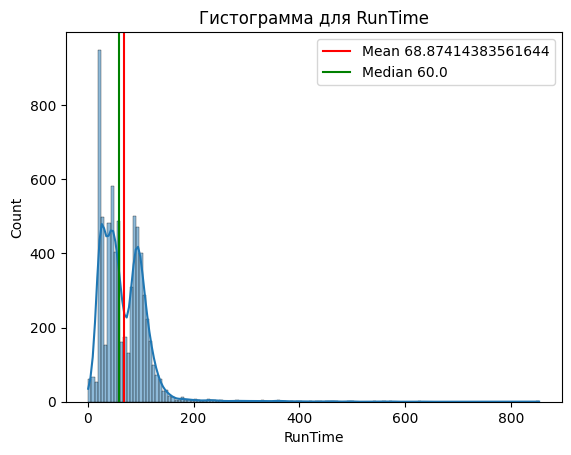

In [19]:
col = 'RunTime'
sns.histplot(df[col], kde=True) # сглаживаемся кривая для гистограммы

mean_value = df[col].mean()
median_value = df[col].median()

plt.axvline(mean_value, color='r', label=f'Mean {mean_value}')
plt.axvline(median_value, color='g', label=f'Median {median_value}')

plt.title(f'Гистограмма для {col}')
plt.legend()

plt.show()

Распределение не является нормальным. Заполним пустые значения поля `RunTime` медианным (хоть и очень близко к среднему) значением по соответствующим жанрам.

In [20]:
# Находим is_ столбцы
is_columns = [col for col in df.columns if col.startswith('is_')]

# Создаем группировочный ключ
df['group_key'] = df[is_columns].astype(str).agg('-'.join, axis=1)

# Вычисляем медианы и применяем transform для заполнения
df['RunTime'] = df.groupby('group_key')['RunTime'].transform(
    lambda x: x.fillna(x.median())
)

print(f"Уникальных групп: {df['group_key'].nunique()}")
print(df['group_key'].value_counts().head())

# Удаляем временный столбец
df.drop('group_key', axis=1, inplace=True)

Уникальных групп: 504
group_key
0-0-0-0-0-0-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0    837
1-0-0-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0    663
0-0-0-0-0-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0    546
0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-1-0-0-0-0-0-0-0-0-0-0-0    495
0-0-0-0-0-1-0-1-0-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0    328
Name: count, dtype: int64


In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 9568 entries, 0 to 9998
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RATING          8168 non-null   float64
 1   STARS           9568 non-null   str    
 2   VOTES           8168 non-null   Int64  
 3   RunTime         9532 non-null   float64
 4   is_Action       9568 non-null   int64  
 5   is_Horror       9568 non-null   int64  
 6   is_Thriller     9568 non-null   int64  
 7   is_Animation    9568 non-null   int64  
 8   is_Adventure    9568 non-null   int64  
 9   is_Drama        9568 non-null   int64  
 10  is_Comedy       9568 non-null   int64  
 11  is_Crime        9568 non-null   int64  
 12  is_Romance      9568 non-null   int64  
 13  is_Mystery      9568 non-null   int64  
 14  is_Fantasy      9568 non-null   int64  
 15  is_History      9568 non-null   int64  
 16  is_Sci-Fi       9568 non-null   int64  
 17  is_Biography    9568 non-null   int64  
 18  is_F

Малая часть `RunTime` всё равно осталась пустой. Можно было бы заполнить средним или медианой по всем строкам, но таких строк 36 из 9568, поэтому удалим эти строки

In [22]:
df.dropna(subset=['RunTime'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 9532 entries, 0 to 9998
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RATING          8151 non-null   float64
 1   STARS           9532 non-null   str    
 2   VOTES           8151 non-null   Int64  
 3   RunTime         9532 non-null   float64
 4   is_Action       9532 non-null   int64  
 5   is_Horror       9532 non-null   int64  
 6   is_Thriller     9532 non-null   int64  
 7   is_Animation    9532 non-null   int64  
 8   is_Adventure    9532 non-null   int64  
 9   is_Drama        9532 non-null   int64  
 10  is_Comedy       9532 non-null   int64  
 11  is_Crime        9532 non-null   int64  
 12  is_Romance      9532 non-null   int64  
 13  is_Mystery      9532 non-null   int64  
 14  is_Fantasy      9532 non-null   int64  
 15  is_History      9532 non-null   int64  
 16  is_Sci-Fi       9532 non-null   int64  
 17  is_Biography    9532 non-null   int64  
 18  is_F

Обработаем самое сложное поле - `STARS`

In [23]:
# Функция разделения поля на Director и Stars
def parse_with_regex(text):
    # Паттерн для поиска Director
    director_pattern = r'Director:\s*\n\s*([^|\n]+(?:\n[^|\n]+)*)'
    director_match = re.search(director_pattern, text, re.MULTILINE)
    
    # Паттерн для поиска Stars
    stars_pattern = r'Stars:\s*\n\s*([^\n]+(?:\n[^\n]+)*)'
    stars_match = re.search(stars_pattern, text, re.MULTILINE)
    
    # Обработка Director
    director = None
    if director_match:
        # Убираем лишние пробелы и переносы строк, объединяем в одну строку
        director = ' '.join([line.strip() for line in director_match.group(1).split('\n') if line.strip()])
    
    # Обработка Stars
    stars = None
    if stars_match:
        # Разбиваем на строки, убираем запятые и объединяем
        stars_lines = [line.strip().rstrip(',') for line in stars_match.group(1).split('\n') if line.strip()]
        stars = ', '.join(stars_lines)
    
    return pd.Series([director, stars])

# Применяем к DataFrame
df[['Director', 'Stars']] = df['STARS'].apply(parse_with_regex)
df.drop(columns=['STARS'], inplace=True)

In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 9532 entries, 0 to 9998
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RATING          8151 non-null   float64
 1   VOTES           8151 non-null   Int64  
 2   RunTime         9532 non-null   float64
 3   is_Action       9532 non-null   int64  
 4   is_Horror       9532 non-null   int64  
 5   is_Thriller     9532 non-null   int64  
 6   is_Animation    9532 non-null   int64  
 7   is_Adventure    9532 non-null   int64  
 8   is_Drama        9532 non-null   int64  
 9   is_Comedy       9532 non-null   int64  
 10  is_Crime        9532 non-null   int64  
 11  is_Romance      9532 non-null   int64  
 12  is_Mystery      9532 non-null   int64  
 13  is_Fantasy      9532 non-null   int64  
 14  is_History      9532 non-null   int64  
 15  is_Sci-Fi       9532 non-null   int64  
 16  is_Biography    9532 non-null   int64  
 17  is_Family       9532 non-null   int64  
 18  is_D

Я думаю, что `Director` так-то сильный фактор. Поэтому предлагаю оставить его и заполнить пропуски чем-нибудь, например `Unknown`. Аналогично предлагаю поступить и со `Stars`.

In [25]:
df['Director'] = df['Director'].fillna('Unknown Director')
df['Stars'] = df['Stars'].fillna('Unknown Star')

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 9532 entries, 0 to 9998
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RATING          8151 non-null   float64
 1   VOTES           8151 non-null   Int64  
 2   RunTime         9532 non-null   float64
 3   is_Action       9532 non-null   int64  
 4   is_Horror       9532 non-null   int64  
 5   is_Thriller     9532 non-null   int64  
 6   is_Animation    9532 non-null   int64  
 7   is_Adventure    9532 non-null   int64  
 8   is_Drama        9532 non-null   int64  
 9   is_Comedy       9532 non-null   int64  
 10  is_Crime        9532 non-null   int64  
 11  is_Romance      9532 non-null   int64  
 12  is_Mystery      9532 non-null   int64  
 13  is_Fantasy      9532 non-null   int64  
 14  is_History      9532 non-null   int64  
 15  is_Sci-Fi       9532 non-null   int64  
 16  is_Biography    9532 non-null   int64  
 17  is_Family       9532 non-null   int64  
 18  is_D

In [27]:
df.head()

,RATING,VOTES,RunTime,is_Action,is_Horror,is_Thriller,is_Animation,is_Adventure,is_Drama,is_Comedy,is_Crime,is_Romance,is_Mystery,is_Fantasy,is_History,is_Sci-Fi,is_Biography,is_Family,is_Documentary,is_Music,is_Sport,is_Short,is_Game-Show,is_Reality-TV,is_Musical,is_War,is_Western,is_Film-Noir,is_Talk-Show,is_News,year_start,year_end,Director,Stars
0,6.1,21062,121.0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,2021,Peter Thorwarth,"Peri Baumeister, Carl Anton Koch, Alexander Sc..."
1,5.0,17870,25.0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,<NA>,Unknown Director,"Chris Wood, Sarah Michelle Gellar, Lena Headey..."
2,8.2,885805,44.0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2010,2022,Unknown Director,"Andrew Lincoln, Norman Reedus, Melissa McBride..."
3,9.2,414849,23.0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2013,<NA>,Unknown Director,"Justin Roiland, Chris Parnell, Spencer Grammer..."
4,NaN,<NA>,148.0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,2021,Matthias Schweighöfer,"Matthias Schweighöfer, Nathalie Emmanuel, Ruby..."


In [28]:
print(df['Director'])

0             Peter Thorwarth
1            Unknown Director
2            Unknown Director
3            Unknown Director
4       Matthias Schweighöfer
                ...          
9993            Nicolai Rohde
9995         Unknown Director
9996    Orlando von Einsiedel
9997         Jovanka Vuckovic
9998         Jovanka Vuckovic
Name: Director, Length: 9532, dtype: str


Возьмём первых двух `STARS` из всех, а затем закодируем `Director`, `STARS1` и `STARS2` исходя из жанра

In [29]:
df[['Star1_temp', 'Star2_temp', 'rest']] = df['Stars'].str.split(',', n=2, expand=True)

# Убираем пробелы с "краёв"
df['Star1'] = df['Star1_temp'].str.strip()
df['Star2'] = df['Star2_temp'].str.strip()

# Заменяем NULL на 'Unknown', если такие есть
df['Star1'] = df['Star1'].fillna('Unknown')
df['Star2'] = df['Star2'].fillna('Unknown')

# Удаляем временные колонки
df = df.drop(columns=['Star1_temp', 'Star2_temp', 'rest', 'Stars'])

In [30]:
# Находим is_ столбцы
is_columns = [col for col in df.columns if col.startswith('is_')]
# Создаем группировочный ключ
df['group_key'] = df[is_columns].astype(str).agg('-'.join, axis=1)

cols = ['Star1', 'Star2', 'Director']
for col in cols:
    # Считаем сколько раз каждый встречается в своей группе
    df['group_count'] = df.groupby(['group_key', f'{col}'])[f'{col}'].transform('count')

    # Считаем общее количество фильмов в каждой группе
    df['group_total'] = df.groupby('group_key')[f'{col}'].transform('count')

    # Процент = количество в группе / всего фильмов в группе
    df[f'{col}_enc'] = df['group_count'] / df['group_total']

# Удалим "лишние" столбцы
df = df.drop(columns=['group_key', 'group_count', 'group_total'])
df = df.drop(columns=cols)


In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 9532 entries, 0 to 9998
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RATING          8151 non-null   float64
 1   VOTES           8151 non-null   Int64  
 2   RunTime         9532 non-null   float64
 3   is_Action       9532 non-null   int64  
 4   is_Horror       9532 non-null   int64  
 5   is_Thriller     9532 non-null   int64  
 6   is_Animation    9532 non-null   int64  
 7   is_Adventure    9532 non-null   int64  
 8   is_Drama        9532 non-null   int64  
 9   is_Comedy       9532 non-null   int64  
 10  is_Crime        9532 non-null   int64  
 11  is_Romance      9532 non-null   int64  
 12  is_Mystery      9532 non-null   int64  
 13  is_Fantasy      9532 non-null   int64  
 14  is_History      9532 non-null   int64  
 15  is_Sci-Fi       9532 non-null   int64  
 16  is_Biography    9532 non-null   int64  
 17  is_Family       9532 non-null   int64  
 18  is_D

In [32]:
df.head()

,RATING,VOTES,RunTime,is_Action,is_Horror,is_Thriller,is_Animation,is_Adventure,is_Drama,is_Comedy,is_Crime,is_Romance,is_Mystery,is_Fantasy,is_History,is_Sci-Fi,is_Biography,is_Family,is_Documentary,is_Music,is_Sport,is_Short,is_Game-Show,is_Reality-TV,is_Musical,is_War,is_Western,is_Film-Noir,is_Talk-Show,is_News,year_start,year_end,Star1_enc,Star2_enc,Director_enc
0,6.1,21062,121.0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,2021,0.142857,0.142857,0.142857
1,5.0,17870,25.0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,<NA>,0.003017,0.001508,0.683258
2,8.2,885805,44.0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2010,2022,0.041667,0.041667,0.208333
3,9.2,414849,23.0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2013,<NA>,0.062112,0.062112,0.726708
4,NaN,<NA>,148.0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,2021,0.500000,0.500000,0.500000


Я подумал, и решил ещё изучить колонку votes_enc_enc

Статистика VOTES:
count          8151.0
mean      15174.65538
std      70169.468866
min               5.0
25%             167.0
50%             796.0
75%            3807.0
max         1713028.0
Name: VOTES, dtype: Float64


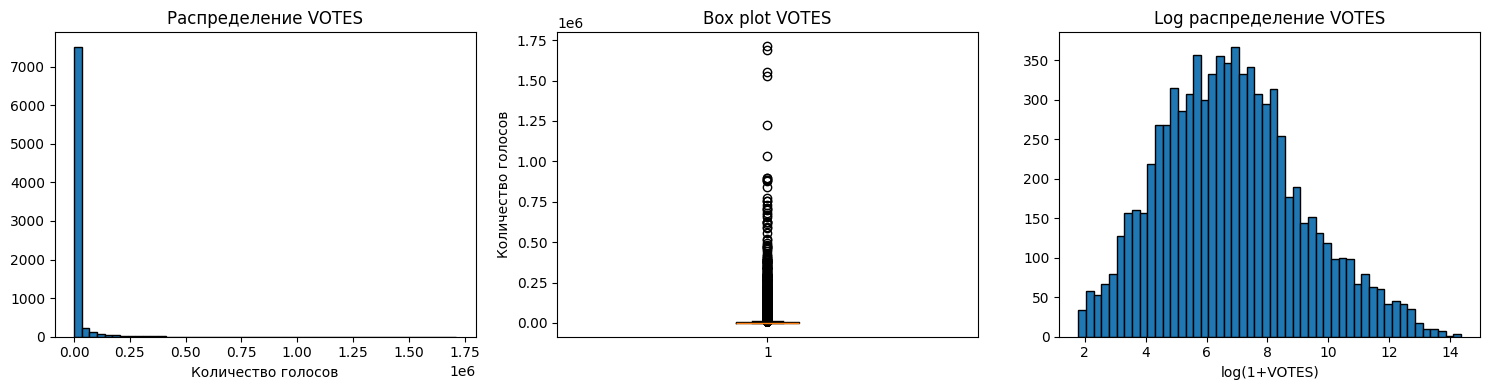


Количество выбросов: 1294 (13.58%)


In [33]:
print("Статистика VOTES:")
print(df['VOTES'].describe())

# Проверим распределение
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Гистограмма
axes[0].hist(df['VOTES'].dropna(), bins=50, edgecolor='black')
axes[0].set_title('Распределение VOTES')
axes[0].set_xlabel('Количество голосов')

# Box plot
axes[1].boxplot(df['VOTES'].dropna())
axes[1].set_title('Box plot VOTES')
axes[1].set_ylabel('Количество голосов')

# Log распределение
axes[2].hist(np.log1p(df['VOTES'].dropna()), bins=50, edgecolor='black')
axes[2].set_title('Log распределение VOTES')
axes[2].set_xlabel('log(1+VOTES)')

plt.tight_layout()
plt.show()

# Проверим на выбросы
Q1 = df['VOTES'].quantile(0.25)
Q3 = df['VOTES'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['VOTES'] < Q1 - 1.5*IQR) | (df['VOTES'] > Q3 + 1.5*IQR)]
print(f"\nКоличество выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Так как после логарифмирования больше похоже на нормальное распределение, то закодируем им

In [34]:
df['votes_enc'] = np.log1p(df['VOTES'])
df = df.drop(columns=['VOTES'])

In [35]:
df.head()

,RATING,RunTime,is_Action,is_Horror,is_Thriller,is_Animation,is_Adventure,is_Drama,is_Comedy,is_Crime,is_Romance,is_Mystery,is_Fantasy,is_History,is_Sci-Fi,is_Biography,is_Family,is_Documentary,is_Music,is_Sport,is_Short,is_Game-Show,is_Reality-TV,is_Musical,is_War,is_Western,is_Film-Noir,is_Talk-Show,is_News,year_start,year_end,Star1_enc,Star2_enc,Director_enc,votes_enc
0,6.1,121.0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,2021,0.142857,0.142857,0.142857,9.955273
1,5.0,25.0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,<NA>,0.003017,0.001508,0.683258,9.790935
2,8.2,44.0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2010,2022,0.041667,0.041667,0.208333,13.694253
3,9.2,23.0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2013,<NA>,0.062112,0.062112,0.726708,12.935672
4,NaN,148.0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2021,2021,0.500000,0.500000,0.500000,<NA>


In [36]:
df.info()

<class 'pandas.DataFrame'>
Index: 9532 entries, 0 to 9998
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RATING          8151 non-null   float64
 1   RunTime         9532 non-null   float64
 2   is_Action       9532 non-null   int64  
 3   is_Horror       9532 non-null   int64  
 4   is_Thriller     9532 non-null   int64  
 5   is_Animation    9532 non-null   int64  
 6   is_Adventure    9532 non-null   int64  
 7   is_Drama        9532 non-null   int64  
 8   is_Comedy       9532 non-null   int64  
 9   is_Crime        9532 non-null   int64  
 10  is_Romance      9532 non-null   int64  
 11  is_Mystery      9532 non-null   int64  
 12  is_Fantasy      9532 non-null   int64  
 13  is_History      9532 non-null   int64  
 14  is_Sci-Fi       9532 non-null   int64  
 15  is_Biography    9532 non-null   int64  
 16  is_Family       9532 non-null   int64  
 17  is_Documentary  9532 non-null   int64  
 18  is_M

Можно ещё заменить Null в `votes_enc`, но мне кажется, что лучше оставить так.

Или удалить все строки с Null'ами